In [4]:
# Ensure dependencies are installed
%pip install pandas openpyxl matplotlib scikit-learn seaborn matplotlib-venn os

from google.colab import drive
drive.mount('/content/drive')

# Import required libraries
import os
import numpy as np
import pandas as pd
from scipy.stats import zscore, chi2
from sklearn.covariance import EmpiricalCovariance
from sklearn.cluster import DBSCAN

# Set up file paths
drive_dir = r'/content/drive/My Drive'
file_path = os.path.join(drive_dir, 'Regression.xlsx')

# Required Libraries
import pandas as pd

# Load the Excel file and import the sheets
try:
    # Load each sheet into separate DataFrames
    factor_output = pd.read_excel(file_path, sheet_name='FactorOutput')
    statistics = pd.read_excel(file_path, sheet_name='Statistics')
    adj_r_squared = pd.read_excel(file_path, sheet_name='Adj_R_Squared')

    # Display the first few rows of each sheet to verify data import
    print("FactorOutput Data:")
    print(factor_output.head(), "\n")

    print("Statistics Data:")
    print(statistics.head(), "\n")

    print("Adj R Squared Data:")
    print(adj_r_squared.head(), "\n")

except Exception as e:
    print(f"An error occurred while loading the Excel file: {e}")


ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FactorOutput Data:
                 Date  Alpha..annualisiert.  Value.Growth  Small.Large  \
0 2016-10-31 12:00:00              0.015941      0.066191     0.143979   
1 2016-11-30 12:00:00              0.010557      0.009500     0.114334   
2 2016-12-31 12:00:00              0.005911      0.058446     0.076206   
3 2017-01-31 12:00:00              0.017806     -0.043341     0.067879   
4 2017-02-28 12:00:00              0.026264     -0.118113     0.031241   

   Momentum  Volatility  
0  0.026032    0.056252  
1  0.024746    0.048692  
2  0.036666    0.070935  
3  0.025677    0.051088  
4 -0.010708    0.032566   

Statistics Data:
   RowNumber  Koeffizienten      S.E.    t-Wert    P-Wert
0          1       0.008533  0.009750  0.

In [21]:
# Preprocess Date and sort by time
factor_output['Date'] = pd.to_datetime(factor_output['Date'])
factor_output = factor_output.sort_values(by='Date')

# Normalize numerical columns
numerical_cols = ['Alpha..annualisiert.', 'Value.Growth', 'Small.Large', 'Momentum', 'Volatility']
scaler = StandardScaler()
factor_output[numerical_cols] = scaler.fit_transform(factor_output[numerical_cols])

# Train-test split (80-20)
train_size = int(0.8 * len(factor_output))
train_data = factor_output.iloc[:train_size]
test_data = factor_output.iloc[train_size:]

# Create sequences for LSTM
timesteps = 10

def create_sequences(data, timesteps, feature_cols):
    X, Y = [], []
    for i in range(timesteps, len(data)):
        X.append(data[feature_cols].iloc[i - timesteps:i].values)
        Y.append(data[feature_cols].iloc[i].values)
    return np.array(X), np.array(Y)

X_train, Y_train = create_sequences(train_data, timesteps, numerical_cols)
X_test, Y_test = create_sequences(test_data, timesteps, numerical_cols)

# Verify sequence shapes
print("Training X shape:", X_train.shape)
print("Training Y shape:", Y_train.shape)
print("Test X shape:", X_test.shape)
print("Test Y shape:", Y_test.shape)


Training X shape: (66, 10, 5)
Training Y shape: (66, 5)
Test X shape: (10, 10, 5)
Test Y shape: (10, 5)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Build the LSTM model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(Y_train.shape[1])  # Output layer matches the number of features in Y
])

model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, Y_train, epochs=50, batch_size=8, validation_split=0.1, shuffle=False)


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 1.1101 - val_loss: 1.0064
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9351 - val_loss: 0.9763
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8283 - val_loss: 0.9391
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7329 - val_loss: 0.8982
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6401 - val_loss: 0.8531
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5564 - val_loss: 0.7975
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5000 - val_loss: 0.7229
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4504 - val_loss: 0.6339
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4025 - val_loss: 0.5623
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3708 - val_loss: 0.5833
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3328 - val_loss: 0.6765
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3055 - val_loss: 0.8053
Epoch 13/50


In [17]:
from sklearn.preprocessing import StandardScaler

# Select numerical columns (excluding 'Date')
numerical_cols = factor_output.columns.difference(['Date'])

# Standardize the numerical data
scaler = StandardScaler()
factor_output[numerical_cols] = scaler.fit_transform(factor_output[numerical_cols])


In [23]:
# Predict on test data
predictions = model.predict(X_test)

# Calculate prediction errors (e.g., Mean Squared Error for each sample)
prediction_errors = np.mean((Y_test - predictions) ** 2, axis=1)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


In [24]:
# Set anomaly threshold
threshold = np.percentile(prediction_errors, 95)

# Identify anomalies
anomalies = prediction_errors > threshold

# Combine results into a DataFrame for analysis
anomaly_results = pd.DataFrame({
    'Date': test_data['Date'].iloc[timesteps:].reset_index(drop=True),
    'PredictionError': prediction_errors,
    'Anomaly': anomalies
})



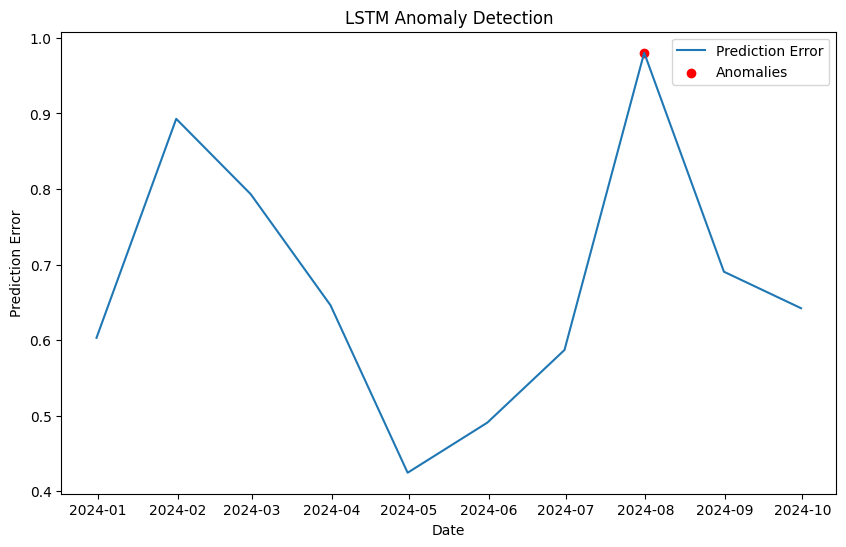

In [25]:
import matplotlib.pyplot as plt

# Plot prediction errors
plt.figure(figsize=(10, 6))
plt.plot(anomaly_results['Date'], anomaly_results['PredictionError'], label="Prediction Error")
plt.scatter(anomaly_results['Date'][anomaly_results['Anomaly']],
            anomaly_results['PredictionError'][anomaly_results['Anomaly']],
            color='red', label="Anomalies")
plt.xlabel("Date")
plt.ylabel("Prediction Error")
plt.title("LSTM Anomaly Detection")
plt.legend()
plt.show()


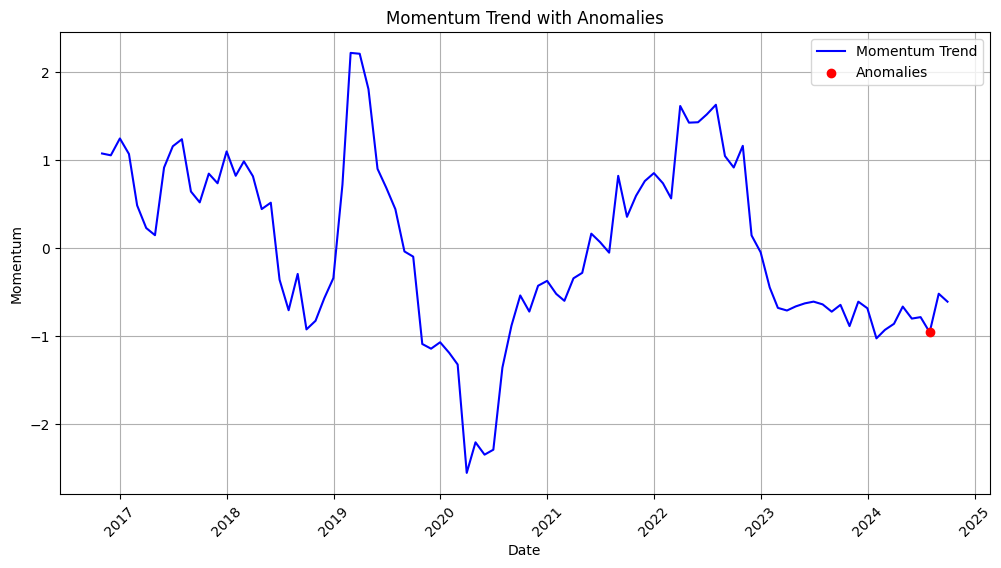

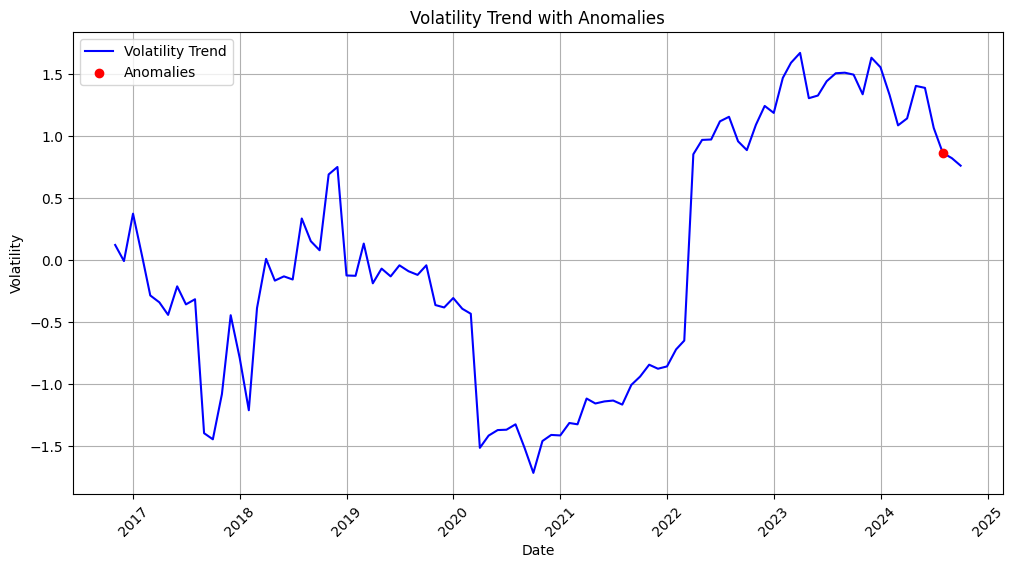

In [29]:
import matplotlib.pyplot as plt

# Features to visualize
features = ['Alpha..annualisiert.', 'Value.Growth', 'Small.Large', 'Momentum', 'Volatility']

# Create a multi-line plot for all features with anomalies
plt.figure(figsize=(14, 8))

# Plot each feature
for feature in features:
    plt.plot(factor_output['Date'], factor_output[feature], label=feature)

# Overlay anomalies
anomalous_dates = anomaly_results[anomaly_results['Anomaly']]['Date']
for feature in features:
    anomalous_values = factor_output.loc[factor_output['Date'].isin(anomalous_dates), feature]
    plt.scatter(anomalous_dates, anomalous_values, label=f"{feature} Anomalies", zorder=5)

# Add labels, legend, and title
plt.xlabel("Date")
plt.ylabel("Feature Values")
plt.title("Trends and Anomalies Across All Features")
plt.legend()
plt.xticks(rotation=45)
plt.grid()

plt.show()

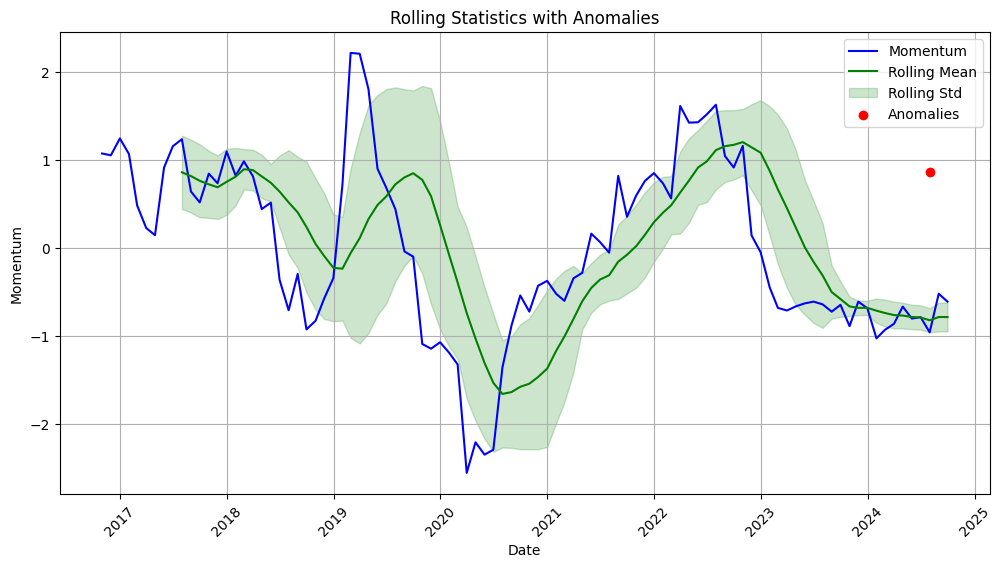

In [30]:
# Calculate rolling mean and standard deviation
factor_output['RollingMean'] = factor_output['Momentum'].rolling(window=10).mean()
factor_output['RollingStd'] = factor_output['Momentum'].rolling(window=10).std()

# Plot rolling statistics with anomalies
plt.figure(figsize=(12, 6))
plt.plot(factor_output['Date'], factor_output['Momentum'], label="Momentum", color='blue')
plt.plot(factor_output['Date'], factor_output['RollingMean'], label="Rolling Mean", color='green')
plt.fill_between(factor_output['Date'],
                 factor_output['RollingMean'] - factor_output['RollingStd'],
                 factor_output['RollingMean'] + factor_output['RollingStd'],
                 color='green', alpha=0.2, label="Rolling Std")
plt.scatter(anomalous_dates, anomalous_values, color='red', label="Anomalies", zorder=5)
plt.xlabel("Date")
plt.ylabel("Momentum")
plt.title("Rolling Statistics with Anomalies")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [32]:
# Summarize anomalies by feature
anomalous_dates = anomaly_results[anomaly_results['Anomaly']]['Date']
anomalous_data = factor_output[factor_output['Date'].isin(anomalous_dates)]

# Calculate summary statistics for anomalies
anomaly_summary = anomalous_data.describe().T  # Transpose for better readability

# Add a column for the count of anomalies
anomaly_summary['Anomaly_Count'] = anomalous_data.count()

# Display the summary
print(anomaly_summary)



                     count                 mean                  min  \
Date                     1  2024-07-31 12:00:00  2024-07-31 12:00:00   
Alpha..annualisiert.   1.0            -0.176041            -0.176041   
Value.Growth           1.0            -0.333373            -0.333373   
Small.Large            1.0              0.40611              0.40611   
Momentum               1.0            -0.960671            -0.960671   
Volatility             1.0             0.864101             0.864101   
RollingMean            1.0            -0.823719            -0.823719   
RollingStd             1.0             0.136841             0.136841   

                                      25%                  50%  \
Date                  2024-07-31 12:00:00  2024-07-31 12:00:00   
Alpha..annualisiert.            -0.176041            -0.176041   
Value.Growth                    -0.333373            -0.333373   
Small.Large                       0.40611              0.40611   
Momentum             